In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report,roc_auc_score,roc_curve 

In [2]:
#Load Dataset
df=pd.read_csv("C:/Users/ADMIN/Downloads/loan-train.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


Loan_Status
Y    422
N    192
Name: count, dtype: int64


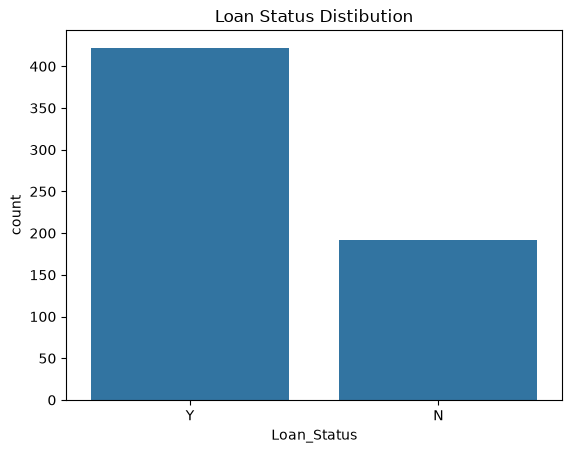

Categorical Features: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
Numerical Features: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_13112\3622087895.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object']).columns.tolist()


In [3]:
#Exploratory Data Analysis
print(df['Loan_Status'].value_counts())
sns.countplot(x='Loan_Status',data=df)
plt.title('Loan Status Distibution')
plt.show()

categorical_features = df.select_dtypes(include=['object']).columns.tolist()
numerical_features = df.select_dtypes(include=['int64','float64']).columns.tolist()

print('Categorical Features:',categorical_features)
print('Numerical Features:',numerical_features)

In [4]:
df =df.drop(columns="Loan_ID")  #Data preprocessing

In [5]:
#converting categorical columns
df["Gender"]=pd.get_dummies(df["Gender"],drop_first=True,dtype=int)

In [6]:
df['Married']=pd.get_dummies(df['Married'],drop_first=True,dtype=int)

In [7]:
df['Self_Employed']=pd.get_dummies(df['Self_Employed'],drop_first=True,dtype=int)

In [8]:
df['Education']=pd.get_dummies(df['Education'],drop_first=True,dtype=int)

In [9]:
df=pd.get_dummies(df,columns=["Property_Area"],drop_first=False,dtype=int)

In [10]:
df.filter(like='Property_Area').columns

Index(['Property_Area_Rural', 'Property_Area_Semiurban',
       'Property_Area_Urban'],
      dtype='str')

In [11]:
df['Loan_Status']=pd.get_dummies(df['Loan_Status'],drop_first=True,dtype=int)

In [12]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,0,0,5849,0.0,NaN,360.0,1.0,1,0,0,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,1,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,1,0,0,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,1,0,0,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,1,0,0,1


In [13]:
df.Dependents.unique()

<StringArray>
['0', '1', '2', '3+', nan]
Length: 5, dtype: str

In [14]:
# Replace '3+' with integer 3
df["Dependents"]=df["Dependents"].replace("3+","3")

# convert to numeric type
df["Dependents"]=pd.to_numeric(df["Dependents"])

In [15]:
df.fillna(0,inplace=True)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0.0,0,0,5849,0.0,0.0,360.0,1.0,1,0,0,1
1,1,1,1.0,0,0,4583,1508.0,128.0,360.0,1.0,0,1,0,0
2,1,1,0.0,0,1,3000,0.0,66.0,360.0,1.0,1,0,0,1
3,1,1,0.0,1,0,2583,2358.0,120.0,360.0,1.0,1,0,0,1
4,1,0,0.0,0,0,6000,0.0,141.0,360.0,1.0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0.0,0,0,2900,0.0,71.0,360.0,1.0,1,1,0,0
610,1,1,3.0,0,0,4106,0.0,40.0,180.0,1.0,1,1,0,0
611,1,1,1.0,0,0,8072,240.0,253.0,360.0,1.0,1,0,0,1
612,1,1,2.0,0,0,7583,0.0,187.0,360.0,1.0,1,0,0,1


In [16]:
df.Dependents.unique()

array([0., 1., 2., 3.])

In [17]:
scaler=StandardScaler()
df[numerical_features]=scaler.fit_transform(df[numerical_features])

In [18]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0.0,0,0,0.072991,-0.554487,-1.599278,0.314162,0.540954,1,0,0,1
1,1,1,1.0,0,0,-0.134412,-0.038732,-0.149160,0.314162,0.540954,0,1,0,0
2,1,1,0.0,0,1,-0.393747,-0.554487,-0.851561,0.314162,0.540954,1,0,0,1
3,1,1,0.0,1,0,-0.462062,0.251980,-0.239792,0.314162,0.540954,1,0,0,1
4,1,0,0.0,0,0,0.097728,-0.554487,-0.001882,0.314162,0.540954,1,0,0,1


In [19]:
x=df.drop(columns=["Loan_Status"])

In [20]:
y=df[["Loan_Status"]]

In [21]:
#Train Test Split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [22]:
#Logistic regression Model Training
model=LogisticRegression(max_iter=650,random_state=42)
model.fit(x_train,y_train)

C:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",650
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbf

In [23]:
x_test.shape

(123, 13)

In [24]:
x_train.shape

(491, 13)

In [25]:
y_test.shape

(123, 1)

In [26]:
# Model Evalation
y_pred=model.predict(x_test)
y_proba=model.predict_proba(x_test)[:,1]

print('Accuracy:',accuracy_score(y_test,y_pred))
print('\nClassificaton Report:\n',classification_report(y_test,y_pred))


Accuracy: 0.7967479674796748

Classificaton Report:
               precision    recall  f1-score   support

           0       0.74      0.53      0.62        38
           1       0.81      0.92      0.86        85

    accuracy                           0.80       123
   macro avg       0.78      0.72      0.74       123
weighted avg       0.79      0.80      0.79       123



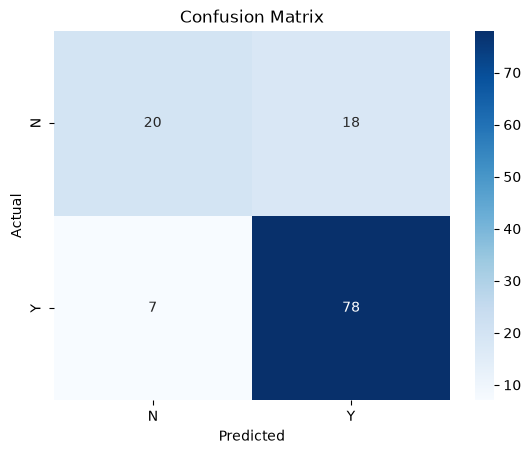

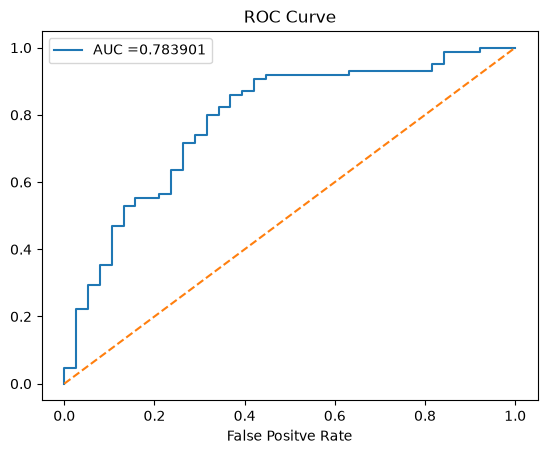

ROC AUC Score: 0.78


In [27]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['N','Y'],yticklabels=['N','Y'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

auc=roc_auc_score(y_test,y_proba)
fpr,tpr,thresholds = roc_curve(y_test,y_proba)
plt.plot(fpr,tpr,label=f'AUC ={auc:2f}')
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel('False Positve Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
print(f'ROC AUC Score: {auc:.2f}')

In [30]:
y_proba=model.predict_proba(x_test)[:,0]
print(y_proba)

[0.78547765 0.10029216 0.2462011  0.20697134 0.11901878 0.19892039
 0.11636118 0.13461192 0.25560418 0.24039869 0.12729588 0.18448436
 0.11118692 0.19858665 0.65076339 0.60678626 0.28684627 0.60299175
 0.54908894 0.20164505 0.58957709 0.43636144 0.62278595 0.11935604
 0.1257064  0.16611888 0.23307198 0.30121159 0.64219549 0.19831223
 0.19800041 0.10984504 0.24791112 0.65185146 0.35449646 0.24023993
 0.77688275 0.10887269 0.26149126 0.12772226 0.20648547 0.28494447
 0.20578584 0.18704005 0.26010031 0.18328087 0.12214514 0.13353935
 0.17157535 0.44589549 0.61296478 0.1206675  0.75936281 0.60528037
 0.40257456 0.25456639 0.5885184  0.19702387 0.17615944 0.73582282
 0.77456681 0.41632199 0.28761365 0.17547625 0.17856291 0.22120317
 0.15811382 0.17632314 0.27051131 0.06463936 0.17292014 0.53637601
 0.11384442 0.28008591 0.16817055 0.19311685 0.19107201 0.19782599
 0.21081483 0.69487926 0.5124634  0.30868816 0.35002101 0.11682461
 0.12332891 0.18072493 0.18315108 0.34174503 0.7349966  0.1946